<a href="https://colab.research.google.com/github/oviccenzo/atividade-de-ia-series-temporais/blob/main/lista_1-serie-temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install tensorflow

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

/tmp/ipykernel_257/1703499125.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed



Analise exploratoria(EDA): PETR4.SA
Price           Close       High        Low       Open    Volume
Ticker       PETR4.SA   PETR4.SA   PETR4.SA   PETR4.SA  PETR4.SA
Date                                                            
2024-12-20  31.871262  32.303707  31.750177  32.139379  59277400
2024-12-23  31.879915  32.044244  31.758831  32.001000  43785600
2024-12-26  32.119564  32.326091  31.966911  31.993852  22920700
2024-12-27  32.020790  32.326092  31.975893  32.326092  24167200
2024-12-30  32.496696  32.658327  32.119560  32.128538  22355600


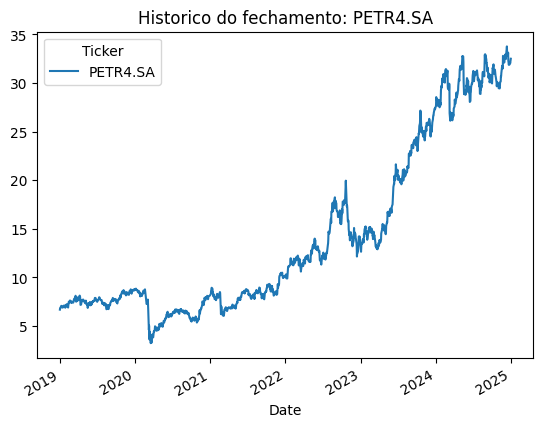

/tmp/ipykernel_257/1703499125.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed



Analise exploratoria(EDA): VALE3.SA
Price           Close       High        Low       Open    Volume
Ticker       VALE3.SA   VALE3.SA   VALE3.SA   VALE3.SA  VALE3.SA
Date                                                            
2024-12-20  48.259750  48.259750  47.119968  47.199484  64919500
2024-12-23  48.462971  48.798722  48.065374  48.303931  18587900
2024-12-26  48.604336  48.948925  48.065370  48.462967  13155800
2024-12-27  48.365780  48.666189  48.118382  48.356942  16635300
2024-12-30  48.197903  48.763377  48.197903  48.507149  11250900


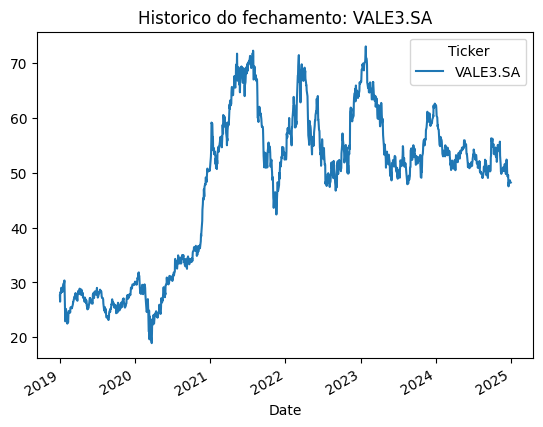

/tmp/ipykernel_257/1703499125.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed



Analise exploratoria(EDA): ITUB4.SA
Price           Close       High        Low       Open    Volume
Ticker       ITUB4.SA   ITUB4.SA   ITUB4.SA   ITUB4.SA  ITUB4.SA
Date                                                            
2024-12-20  24.455967  24.471495  24.114360  24.114360  60210112
2024-12-23  23.982376  24.308455  23.873683  24.168707  31425454
2024-12-26  24.137655  24.246350  23.904741  23.951325  23278278
2024-12-27  23.896971  24.246343  23.896971  24.184231  15418543
2024-12-30  23.858158  24.122128  23.858158  23.966851  32151480


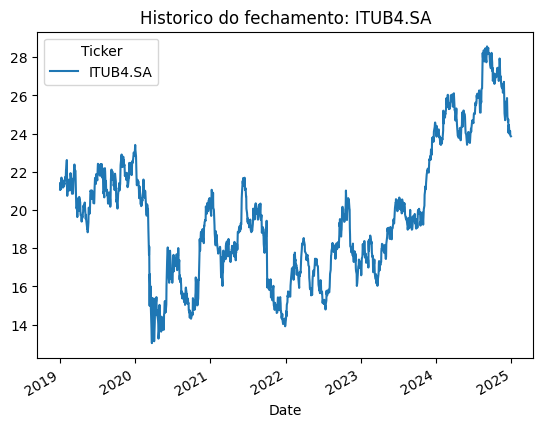

/tmp/ipykernel_257/1703499125.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed



Analise exploratoria(EDA): AAPL
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-12-24  256.797180  256.807105  253.902972  254.101897  23234700
2024-12-26  257.612701  258.686851  256.230269  256.787224  27237100
2024-12-27  254.201370  257.294489  251.685117  256.429191  42355300
2024-12-30  250.829773  252.122713  249.387654  250.859609  35557500
2024-12-31  249.059464  251.903926  248.074837  251.068493  39480700


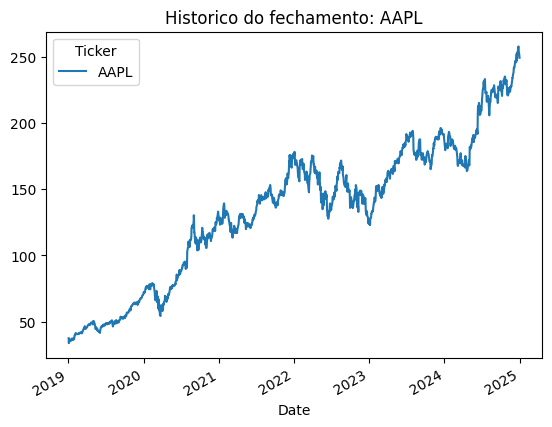

/tmp/ipykernel_257/1703499125.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=data_inicio, end=data_fim)
[*********************100%***********************]  1 of 1 completed



Analise exploratoria(EDA): TSLA
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2024-12-24  462.279999  462.779999  435.140015  435.899994  59551800
2024-12-26  454.130005  465.329987  451.019989  465.160004  76366400
2024-12-27  431.660004  450.000000  426.500000  449.519989  82666800
2024-12-30  417.410004  427.000000  415.750000  419.399994  64941000
2024-12-31  403.839996  427.929993  402.540009  423.790009  76825100


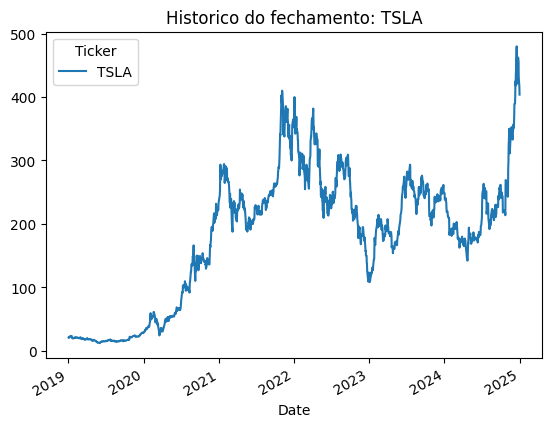

In [ ]:
tickers = ["PETR4.SA","VALE3.SA","ITUB4.SA","AAPL","TSLA"]
data_inicio = "2019-01-01"
data_fim = "2025-01-01"

def baixar_e_analisar(ticker):
  df = yf.download(ticker, start=data_inicio, end=data_fim)
  print(f"\nAnalise exploratoria(EDA): {ticker}")
  print(df.tail())
  df["Close"].plot(title=f"Historico do fechamento: {ticker}")
  plt.show()
  return df

dados_acoes = {t: baixar_e_analisar(t) for t in tickers}

In [ ]:
LOOKBACK = 60

def preparar_sequencial(dados, lookback):
  X, y = [], []
  for i in range(lookback, len(dados)):
    X.append(dados[i-lookback:i, 0])
    y.append(dados[i, 0])
  return np.array(X), np.array(y)

scaler = MinMaxScaler(feature_range=(0,1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step


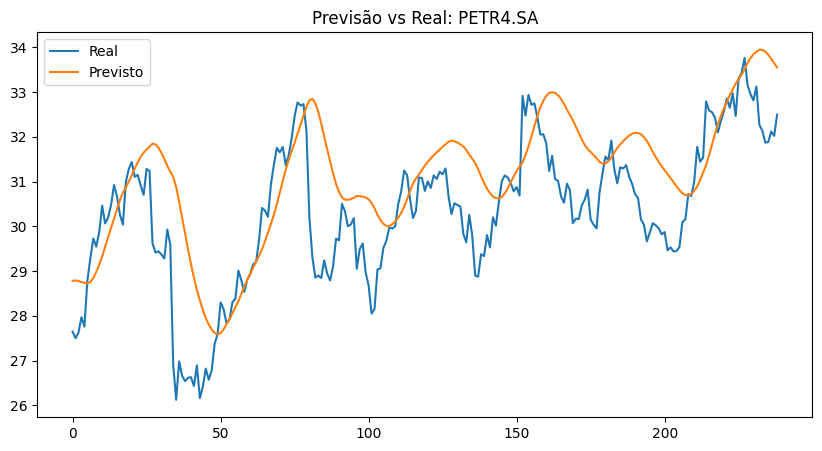

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


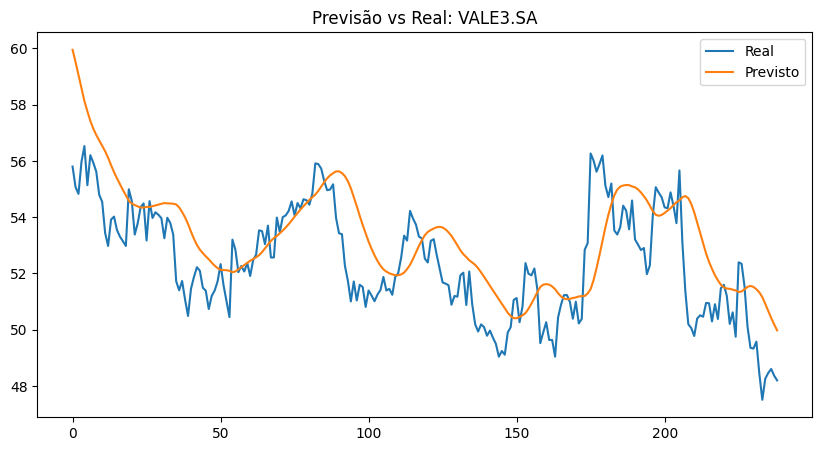

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


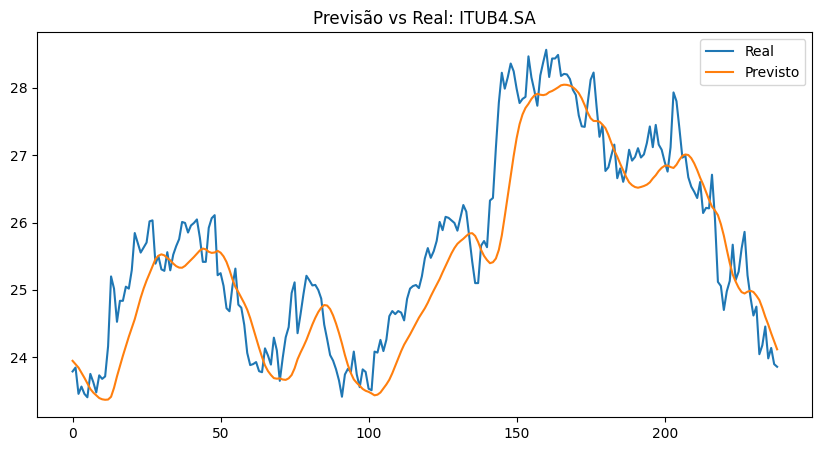

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


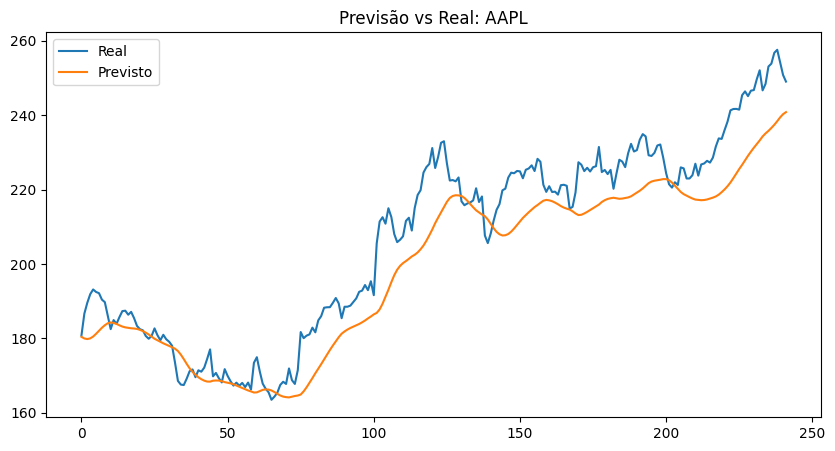

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


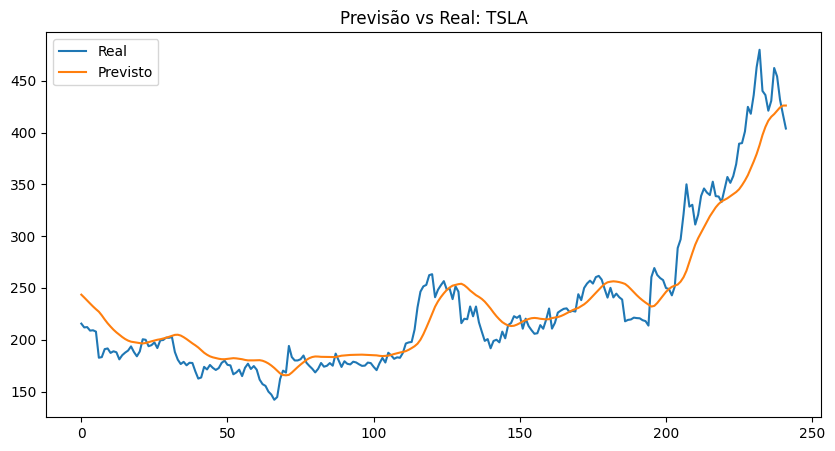


--- Métricas Finais para o meu README do github---
PETR4.SA: MAE = 1.07, RMSE = 1.40
VALE3.SA: MAE = 1.37, RMSE = 1.73
ITUB4.SA: MAE = 0.49, RMSE = 0.62
AAPL: MAE = 8.26, RMSE = 10.16
TSLA: MAE = 17.36, RMSE = 23.21


In [ ]:
resultados_metricas = {}

for ticker in tickers:
  df = dados_acoes[ticker][["Close"]].values
  scaled_data = scaler.fit_transform(df)

  tamanho_treino = int(len(scaled_data) * 0.8)
  train_data = scaled_data[:tamanho_treino]
  test_data = scaled_data[tamanho_treino:]

  X_train, y_train = preparar_sequencial(train_data, LOOKBACK)
  X_test, y_test = preparar_sequencial(test_data, LOOKBACK)

  X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
  X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

  model = Sequential([
      LSTM(50, return_sequences=True, input_shape=(LOOKBACK, 1)),
      Dropout(0.2),
      LSTM(50, return_sequences=False),
      Dropout(0.2),
      Dense(25),
      Dense(1)
  ])
  model.compile(optimizer="adam", loss='mean_squared_error')
  model.fit(X_train, y_train, batch_size=32, epochs=5, verbose=0)

  predictions = model.predict(X_test)
  predictions = scaler.inverse_transform(predictions)
  y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

  mae = mean_absolute_error(y_test_real, predictions)
  rmse = np.sqrt(mean_absolute_error(y_test_real, predictions))
  resultados_metricas[ticker] = {"MAE": mae, "RMSE" : rmse}

  plt.figure(figsize=(10,5))
  plt.plot(y_test_real, label="Real")
  plt.plot(predictions, label="Previsto")
  plt.title(f"Previsão vs Real: {ticker}")
  plt.legend()
  plt.show()

print("\n--- Métricas Finais para o meu README do---")
for t, m in resultados_metricas.items():
    print(f"{t}: MAE = {m['MAE']:.2f}, RMSE = {m['RMSE']:.2f}")